# Línea base y métricas iniciales — Beijing PM2.5

Este notebook construye y evalúa dos líneas base de predicción: naïve simple y naïve estacional, para las dos configuraciones definidas previamente de ventana de entrada 24h→1h y 48h→6h y horizonte de predicción. 

A partir de los tensores generados en 1. Preparación de los datos.ipynb y de los parámetros de normalización de PM2.5, se calculan las métricas RMSE y MAE en unidades originales (µg/m³) sobre los conjuntos de validación y prueba. Estos resultados servirán como referencia para determinar si los modelos posteriores, como MLP y LSTM, logran una mejora real frente a métodos de predicción sencillos.


## 1. Entorno y reproducibilidad

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 8
np.random.seed(SEED)
torch.manual_seed(SEED)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("Semilla fijada:", SEED)


pandas: 2.2.1
numpy: 1.26.4
torch: 2.13.0
Semilla fijada: 8


## 2. Recuperar la escala original de PM2.5

Los tensores de ventanas se guardaron normalizados mediante un z-score. Esa transformación es útil para trabajar con modelos y evitar que las variables de distintas escalas dominen el aprendizaje, pero sus valores dejan de tener una interpretación directa en el dominio.

Antes de calcular las métricas, se desnormalizan el objetivo y las predicciones usando la media y la desviación estándar de PM2.5 calculadas **exclusivamente con train** en el notebook de preparación. Así, RMSE y MAE quedan expresados en µg/m³:

- **MAE:** error absoluto medio; indica cuántos µg/m³ nos alejamos, en promedio, del valor real.
- **RMSE:** raíz del error cuadrático medio; está en las mismas unidades, pero penaliza más los errores grandes, es relevante cuando hay episodios de contaminación elevada.

Las métricas se calcularán por separado para train, validación y test.

In [2]:
FEATURES = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
            "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
TARGET = "PM2.5"
IDX_TARGET = FEATURES.index(TARGET)

CLEANED_DATA_DIR = Path("data/processed")

train_raw = pd.read_csv(CLEANED_DATA_DIR / "train.csv", parse_dates=["datetime"])
media_pm25 = train_raw["PM2.5"].mean()
desv_pm25 = train_raw["PM2.5"].std()

print(f"Media de PM2.5 (train): {media_pm25:.3f} µg/m³")
print(f"Desviación de PM2.5 (train): {desv_pm25:.3f} µg/m³")

def desnormalizar(valor_z):
    return valor_z * desv_pm25 + media_pm25


Media de PM2.5 (train): 80.360 µg/m³
Desviación de PM2.5 (train): 80.334 µg/m³


## 3. Cargar los tensores de las dos configuraciones

Se evalúan dos configuraciones con distinta dificultad, que combinan tamaño de ventana y horizonte de predicción:

- `A_24h_a_1h`: se observan las últimas 24 horas para predecir el PM2.5 de la hora inmediatamente siguiente.
- `B_48h_a_6h`: se observan las últimas 48 horas para predecir el valor seis horas después del final de la ventana.

La configuración A representa una extrapolación corta: el punto a predecir está a solo una hora del último dato observado.

La configuración B aumenta el horizonte a seis horas: aunque la ventana de entrada es más larga y aporta más contexto histórico, el último valor observado queda más lejos en el tiempo del instante que se quiere predecir, así que es esperable que el error crezca.

Cada tensor guardado contiene `X`, con forma `(ejemplos, horas, variables)`, y `y`, con el valor objetivo correspondiente a cada ejemplo. Dentro de la última dimensión de `X`, la variable objetivo (PM2.5) ocupa la posición `IDX_TARGET`, la misma que se usa para calcular las líneas base directamente sobre la ventana de entrada.

In [3]:
CONFIGURACIONES = {
    "A_24h_a_1h": {"window": 24, "horizon": 1},
    "B_48h_a_6h": {"window": 48, "horizon": 6},
}

PYTORCH_DIR_PATH = Path('data/pytorch_tensors')

tensores = {}
for nombre_config in CONFIGURACIONES:
    tensores[nombre_config] = {}
    for nombre_split in ["train", "val", "test"]:
        d = torch.load(f"{PYTORCH_DIR_PATH}/{nombre_config}_{nombre_split}.pt")
        tensores[nombre_config][nombre_split] = (d["X"], d["y"])
        print(f"{nombre_config} / {nombre_split}: X {tuple(d['X'].shape)} | y {tuple(d['y'].shape)}")


A_24h_a_1h / train: X (315360, 24, 11) | y (315360,)
A_24h_a_1h / val: X (52704, 24, 11) | y (52704,)
A_24h_a_1h / test: X (51840, 24, 11) | y (51840,)
B_48h_a_6h / train: X (315012, 48, 11) | y (315012,)
B_48h_a_6h / val: X (52356, 48, 11) | y (52356,)
B_48h_a_6h / test: X (51492, 48, 11) | y (51492,)


## 4. Líneas base: un piso mínimo antes de entrenar modelos

Una línea base es una estrategia de referencia que permite responder a una pregunta esencial: **¿el modelo aprendido aporta información frente a una regla muy sencilla?** En este notebook no se ajustan pesos ni parámetros con los datos: cada predicción se obtiene copiando un valor de PM2.5 que ya está disponible dentro de la ventana de entrada. Por eso las líneas base no "aprenden", pero sí establecen el nivel mínimo de desempeño que una futura MLP o LSTM debe superar para justificar su uso.

Se comparan dos supuestos distintos sobre la dinámica de la contaminación:

- **Naïve simple (persistencia):** predice el último valor de PM2.5 observado dentro de la ventana, es decir, el dato inmediatamente anterior al instante objetivo. Supone que nada cambia de forma brusca entre una hora y la siguiente.

- **Naïve estacional (rezago de 24 horas):** predice el valor de PM2.5 registrado exactamente 24 horas antes del instante objetivo, calculando la posición correspondiente dentro de la ventana según `window` y `horizon`. Supone que el patrón de hoy se repite aproximadamente igual al de ayer a la misma hora.

Se miden ambas porque, antes de observar los resultados, no se sabe cuál de las dos hipótesis describe mejor el PM2.5 de Beijing. La comparación funciona además como prueba diagnóstica sobre la naturaleza de la serie: si gana el naïve simple, la continuidad hora a hora es más informativa que repetir mecánicamente el día anterior; si gana el estacional, existe una señal diaria lo bastante estable como para explotarla de forma directa.

In [4]:
def naive_simple(X, idx_target):
    """Predicción = último valor observado de la variable objetivo en la ventana."""
    return X[:, -1, idx_target]


def naive_estacional(X, idx_target, window, horizon, lag=24):
    """Predicción = valor de la variable objetivo 'lag' horas antes del objetivo real.
    La posición dentro de la ventana se calcula como window + horizon - 1 - lag.
    """
    pos = window + horizon - 1 - lag
    assert 0 <= pos < window, (
        f"El horizonte estacional (lag={lag}h) queda fuera de la ventana "
        f"(window={window}, horizon={horizon}). Ajusta la ventana o el lag."
    )
    return X[:, pos, idx_target]


In [7]:
resultados_metricas = []

for nombre_config, params in CONFIGURACIONES.items():
    for nombre_split in ["train", "val", "test"]:
        X, y = tensores[nombre_config][nombre_split]

        pred_simple = naive_simple(X, IDX_TARGET)
        pred_estacional = naive_estacional(X, IDX_TARGET, params["window"], params["horizon"])

        y_real = desnormalizar(y)
        pred_simple_real = desnormalizar(pred_simple)
        pred_estacional_real = desnormalizar(pred_estacional)

        for nombre_baseline, pred in [("naive_simple", pred_simple_real),
                                        ("naive_estacional", pred_estacional_real)]:
            rmse = torch.sqrt(torch.mean((pred - y_real) ** 2)).item()
            mae = torch.mean(torch.abs(pred - y_real)).item()
            resultados_metricas.append({
                "configuracion": nombre_config,
                "conjunto": nombre_split,
                "linea_base": nombre_baseline,
                "RMSE": round(rmse, 2),
                "MAE": round(mae, 2),
                "n_ejemplos": len(y_real),
            })

tabla_resultados = pd.DataFrame(resultados_metricas)
tabla_resultados


,configuracion,conjunto,linea_base,RMSE,MAE,n_ejemplos
0,A_24h_a_1h,train,naive_simple,20.42,10.65,315360
1,A_24h_a_1h,train,naive_estacional,87.88,58.60,315360
2,A_24h_a_1h,val,naive_simple,15.25,8.80,52704
3,A_24h_a_1h,val,naive_estacional,66.01,44.52,52704
4,A_24h_a_1h,test,naive_simple,22.88,11.45,51840
5,A_24h_a_1h,test,naive_estacional,105.22,71.36,51840
6,B_48h_a_6h,train,naive_simple,55.38,33.04,315012
7,B_48h_a_6h,train,naive_estacional,87.91,58.63,315012
8,B_48h_a_6h,val,naive_simple,40.76,25.45,52356
9,B_48h_a_6h,val,naive_estacional,66.01,44.45,52356


### Verificación visual: predicción frente a realidad en un tramo de test

Las métricas resumen todo el conjunto, pero una gráfica permite confirmar que la indexación temporal es correcta. Se muestran las primeras 200 horas de test para la configuración `A_24h_a_1h`, revisando si cada línea sigue la tendencia general y reacciona con rapidez ante picos o caídas: la persistencia debería acercarse a la realidad cuando el PM2.5 cambia gradualmente, mientras que la estacional puede desviarse si el día anterior tuvo una intensidad distinta.

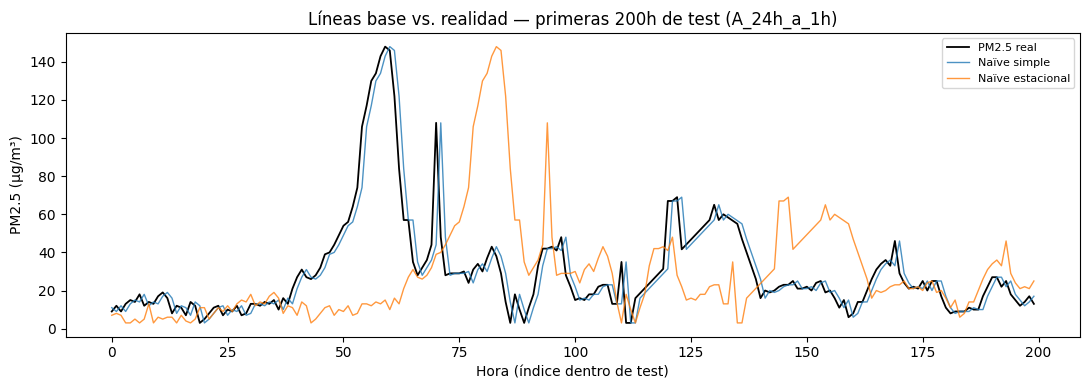

In [ ]:
config_ejemplo = "A_24h_a_1h"
X_test, y_test = tensores[config_ejemplo]["test"]

n_mostrar = 200  # primeras 200 horas de test, suficiente para ver el patrón
y_real_plot = desnormalizar(y_test[:n_mostrar]).numpy()
pred_simple_plot = desnormalizar(naive_simple(X_test[:n_mostrar], IDX_TARGET)).numpy()
pred_estacional_plot = desnormalizar(
    naive_estacional(X_test[:n_mostrar], IDX_TARGET,
                      CONFIGURACIONES[config_ejemplo]["window"],
                      CONFIGURACIONES[config_ejemplo]["horizon"])
).numpy()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y_real_plot, label="PM2.5 real", color="black", linewidth=1.3)
ax.plot(pred_simple_plot, label="Naïve simple", color="tab:blue", linewidth=1, alpha=0.8)
ax.plot(pred_estacional_plot, label="Naïve estacional", color="tab:orange", linewidth=1, alpha=0.8)
ax.set_title(f"Líneas base vs. realidad — primeras {n_mostrar}h de test ({config_ejemplo})")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlabel("Hora (índice dentro de test)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5. Interpretación y conclusiones

- El naïve simple es claramente superior al naïve estacional: en test, para `A_24h_a_1h`, el RMSE baja de 105.22 µg/m³ (estacional) a 22.88 µg/m³ (simple), y el MAE de 71.36 a 11.45 µg/m³; en `B_48h_a_6h`, el RMSE pasa de 105.57 a 66.14 y el MAE de 71.80 a 38.50. Es decir copiar la hora anterior resulta mucho más preciso que copiar el mismo momento del día anterior.

- Esto sugiere que la contaminación cambia de forma más gradual hora a hora que de manera idéntica entre días. Puede existir un patrón diario, pero no es lo bastante estable como para usarlo sin más información, ya que meteorología, emisiones y episodios puntuales alteran la intensidad del ciclo.

- Predecir a seis horas es más difícil que predecir a una hora: el naïve simple aumenta su RMSE de 22.88 a 66.14 µg/m³ entre `A_24h_a_1h` y `B_48h_a_6h`, lo que evidencia el costo de alejar el objetivo del último valor observado, incluso con una ventana histórica más larga.

- El verdadero reto para la LSTM no es superar una predicción aleatoria, sino aprender representaciones que aporten información adicional a la persistencia, detectando cuándo conviene abandonar el último valor observado y combinando la historia de PM2.5 con las variables meteorológicas y de otros contaminantes para anticipar cambios, picos y el efecto del horizonte de predicción. La línea base queda así como un criterio mínimo, interpretable y reproducible para medir si el aprendizaje profundo ofrece una mejora real.